In [1]:
%cd ..

import sys
import os

from driverEngine import driverEngine
from utils.data_utils import load_config
import matplotlib.pyplot as plt
import numpy as np
from utils.caption_utils import parse_string

/home/ximeng/anaconda3/envs/dllm/lib/python3.10/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/ximeng/Documents/NaviDrive


In [2]:
config_path = "configs/qwen_vl_2B_sft_cmd.yaml"

config = load_config(config_path)
trainer = driverEngine(config)
trainer.load_model_from_checkpoint()

Loading model from checkpoint: checkpoints/qwen_vl_2B_sft_cmd
Loading visual model: checkpoints/qwen_vl_2B_sft_cmd with attention: flash_attention_2


Loading weights:   0%|          | 0/625 [00:00<?, ?it/s]

Model loaded successfully from checkpoint.


In [3]:
def plot_debug_results(pred_outputs, gt_wp_raw, command="Unknown"):
    plt.figure(figsize=(11, 8))
    
    gt_pts = parse_string(gt_wp_raw)
    gt_x = gt_pts[:, 0]
    gt_y = gt_pts[:, 1]
    
    plt.plot(gt_x, gt_y, color='black', marker='D', markersize=6, 
             linewidth=3, label='Ground Truth', zorder=10)

    colors = ['#FF0000', '#00FF00', '#0000FF', '#FF00FF', '#00FFFF', '#FFA500']
    
    ade_list = []

    for i, raw_str in enumerate(pred_outputs):
        try:
            pred_pts = parse_string(raw_str)
            px = pred_pts[:, 0]
            py = pred_pts[:, 1]
            
            min_len = min(len(gt_pts), len(pred_pts))
            if min_len == 0:
                continue
                
            errors = np.sqrt((px[:min_len] - gt_x[:min_len])**2 + (py[:min_len] - gt_y[:min_len])**2)
            ade = np.mean(errors)
            ade_list.append(ade)

            plt.plot(px, py, color=colors[i], linestyle='--', marker='.', 
                     alpha=0.7, label=f'C{i+1} (ADE: {ade:.2f}m)')
            
        except Exception as e:
            print(f"Trajectory parsing error for candidate {i+1} : {e}")

    if ade_list:
        min_ade = min(ade_list)
        stats_text = f'minADE: {min_ade:.4f} m'
        plt.text(0.95, 0.05, stats_text, transform=plt.gca().transAxes, 
                 fontsize=12, fontweight='bold', va='bottom', ha='right',
                 bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        min_ade = float('inf')

    plt.axhline(0, color='gray', linewidth=0.5, alpha=0.5)
    plt.axvline(0, color='gray', linewidth=0.5, alpha=0.5)
    plt.xlabel('Lateral Distance X (m)')
    plt.ylabel('Longitudinal Distance Y (m)')
    

    plt.title(f"Trajectory Debug [Command: {command}]\nminADE: {min_ade:.4f}m")
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Candidates")
    plt.axis('equal') 
    plt.grid(True, linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.show()

    return min_ade


============================== PROMPT ==============================
Perception: The ego-vehicle is approaching an intersection with active pedestrian traffic and a black SUV is on the right side, partially obstructing the lane. Traffic lights are yellow, indicating an impending stop. Pedestrians are visible crossing at crosswalks and on sidewalks, requiring caution.

Action: Prepare to stop at the intersection. Begin decelerating smoothly to comply with the yellow traffic light and ensure pedestrian safety.

Reasoning: The current velocity and deceleration suggest the vehicle is approaching a stop point. The presence of pedestrians and the yellow light mandates a cautious stop to avoid potential collisions and ensure pedestrian safety at the crossing.

Current Dynamics:
- Velocity: 8.42 m/s
- Yaw Rate: -0.06 rad/s
- Acceleration (Longitudinal x, Lateral y): [-0.3, -0.3]
Past Trajectory (2Hz): (-16.81, -0.81), (-12.61, -0.44), (-8.45, -0.18), (-4.28, -0.03)
High-level Command: <Slight

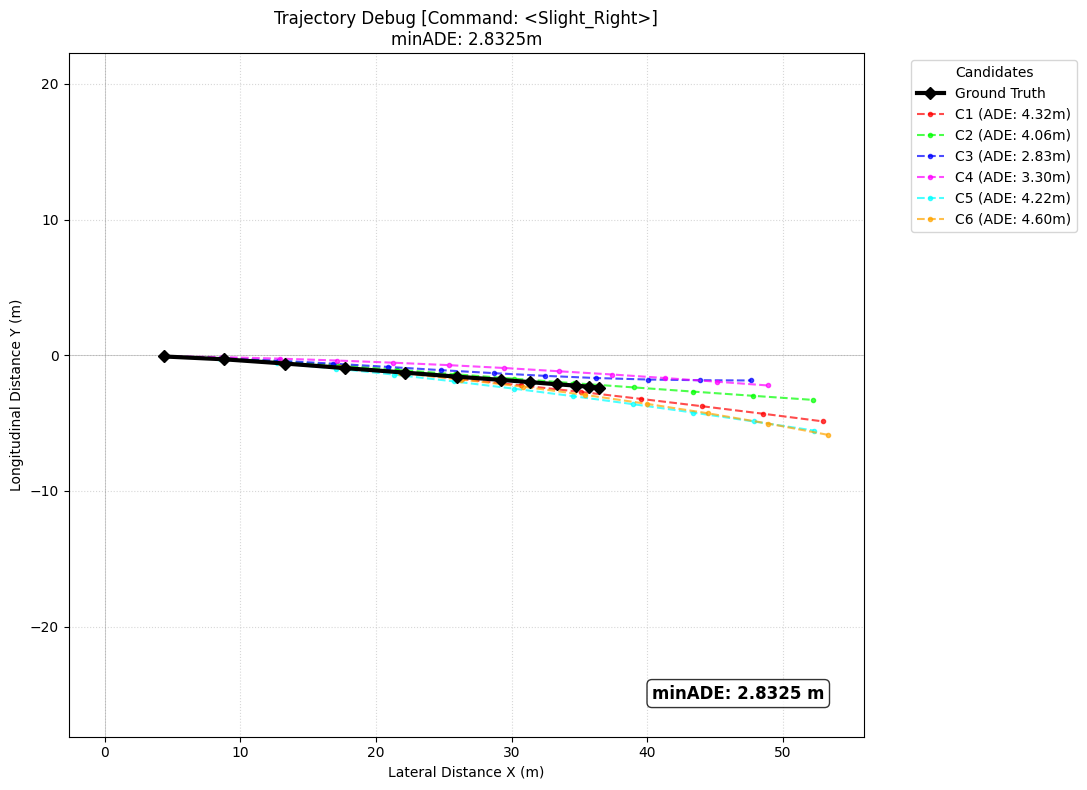

2.8324505580087878

In [4]:
outputs, gt_wp, command = trainer.inference_once(temperature=0.7, top_p=0.8, sample_index=26)
plot_debug_results(outputs, gt_wp, command)